In [5]:
from utils.binaries import *
from utils.plotting import *
from utils import CONSTANTS
from utils.auger.fd import *
import json

In [6]:
with open("data.json", 'r') as f:
    data = json.load(f)

print(data)

{'meta': {'type': 'auger data release', 'release': 1, 'format': 2, 'reconstruction': {'software': 'Offline', 'version': 'v3r99p1-icrc-2019'}}, 'info': {'id': 62636056300, 'sdid': 2682370, 'gpstime': 842849376, 'date': '2006-09-21T04:49:22Z'}, 'flags': {'hdSpectrum': 0, 'hdCalib': 1, 'hdXmax': 1, 'multiEye': 1, 'sd1500': 1, 'sd750': 0}, 'fdrec': [{'id': 1, 'gpsnanotime': 149013878, 'hdSpectrumEye': 0, 'hdCalibEye': 1, 'hdXmaxEye': 1, 'theta': 45.91, 'dtheta': 0.22, 'phi': 222.13, 'dphi': 0.81, 'l': 345.71, 'b': -32.33, 'ra': 301.46, 'dec': -52.74, 'totalEnergy': 4.649, 'dtotalEnergy': 0.356, 'calEnergy': 4.015, 'dcalEnergy': 0.303, 'xmax': 735.9, 'dxmax': 10.3, 'heightXmax': 5703.64, 'distXmax': 18036.15, 'dEdXmax': 7.25, 'ddEdXmax': 0.19, 'x': 1264.93, 'dx': 48.03, 'y': -17387.22, 'dy': 74.77, 'z': -43.63, 'easting': 478563.73, 'northing': 6081829.47, 'altitude': 1381.48, 'cherenkovFraction': 0.07, 'minViewAngle': 103.35, 'uspL': 219.43, 'duspL': 7.76, 'uspR': 0.28, 'duspR': 0.05, 'hot

In [7]:
data.keys()

def calc_profile(eye):

    Xmax = eye["xmax"]
    dEXmax = eye["dEdXmax"]
    L = eye["uspL"]
    R = eye["uspR"]

    pow1 = lambda x: np.power(1 + R*(x-Xmax)/L, np.power(R, -2))
    pow2 = lambda x: np.exp(-(x - Xmax) / (R*L))

    return lambda x: dEXmax * pow1(x) * pow2(x)

19:34:56 (  +16.1s) [DEBUG  ] -- font size set to 9.5
19:34:56 (    +1ms) [DEBUG  ] -- label size set to 13.0
19:34:56 (    +0ms) [DEBUG  ] -- figure size set to [3.3, 2.5]
19:34:56 (    +0ms) [DEBUG  ] -- markersize set to 2.0
19:34:56 (    +1ms) [DEBUG  ] -- usetex set to False


Text(0, 0.5, 'd$E$/d$X$ / $\\mathrm{PeV}/(\\mathrm{g}/\\mathrm{cm}^2)$')

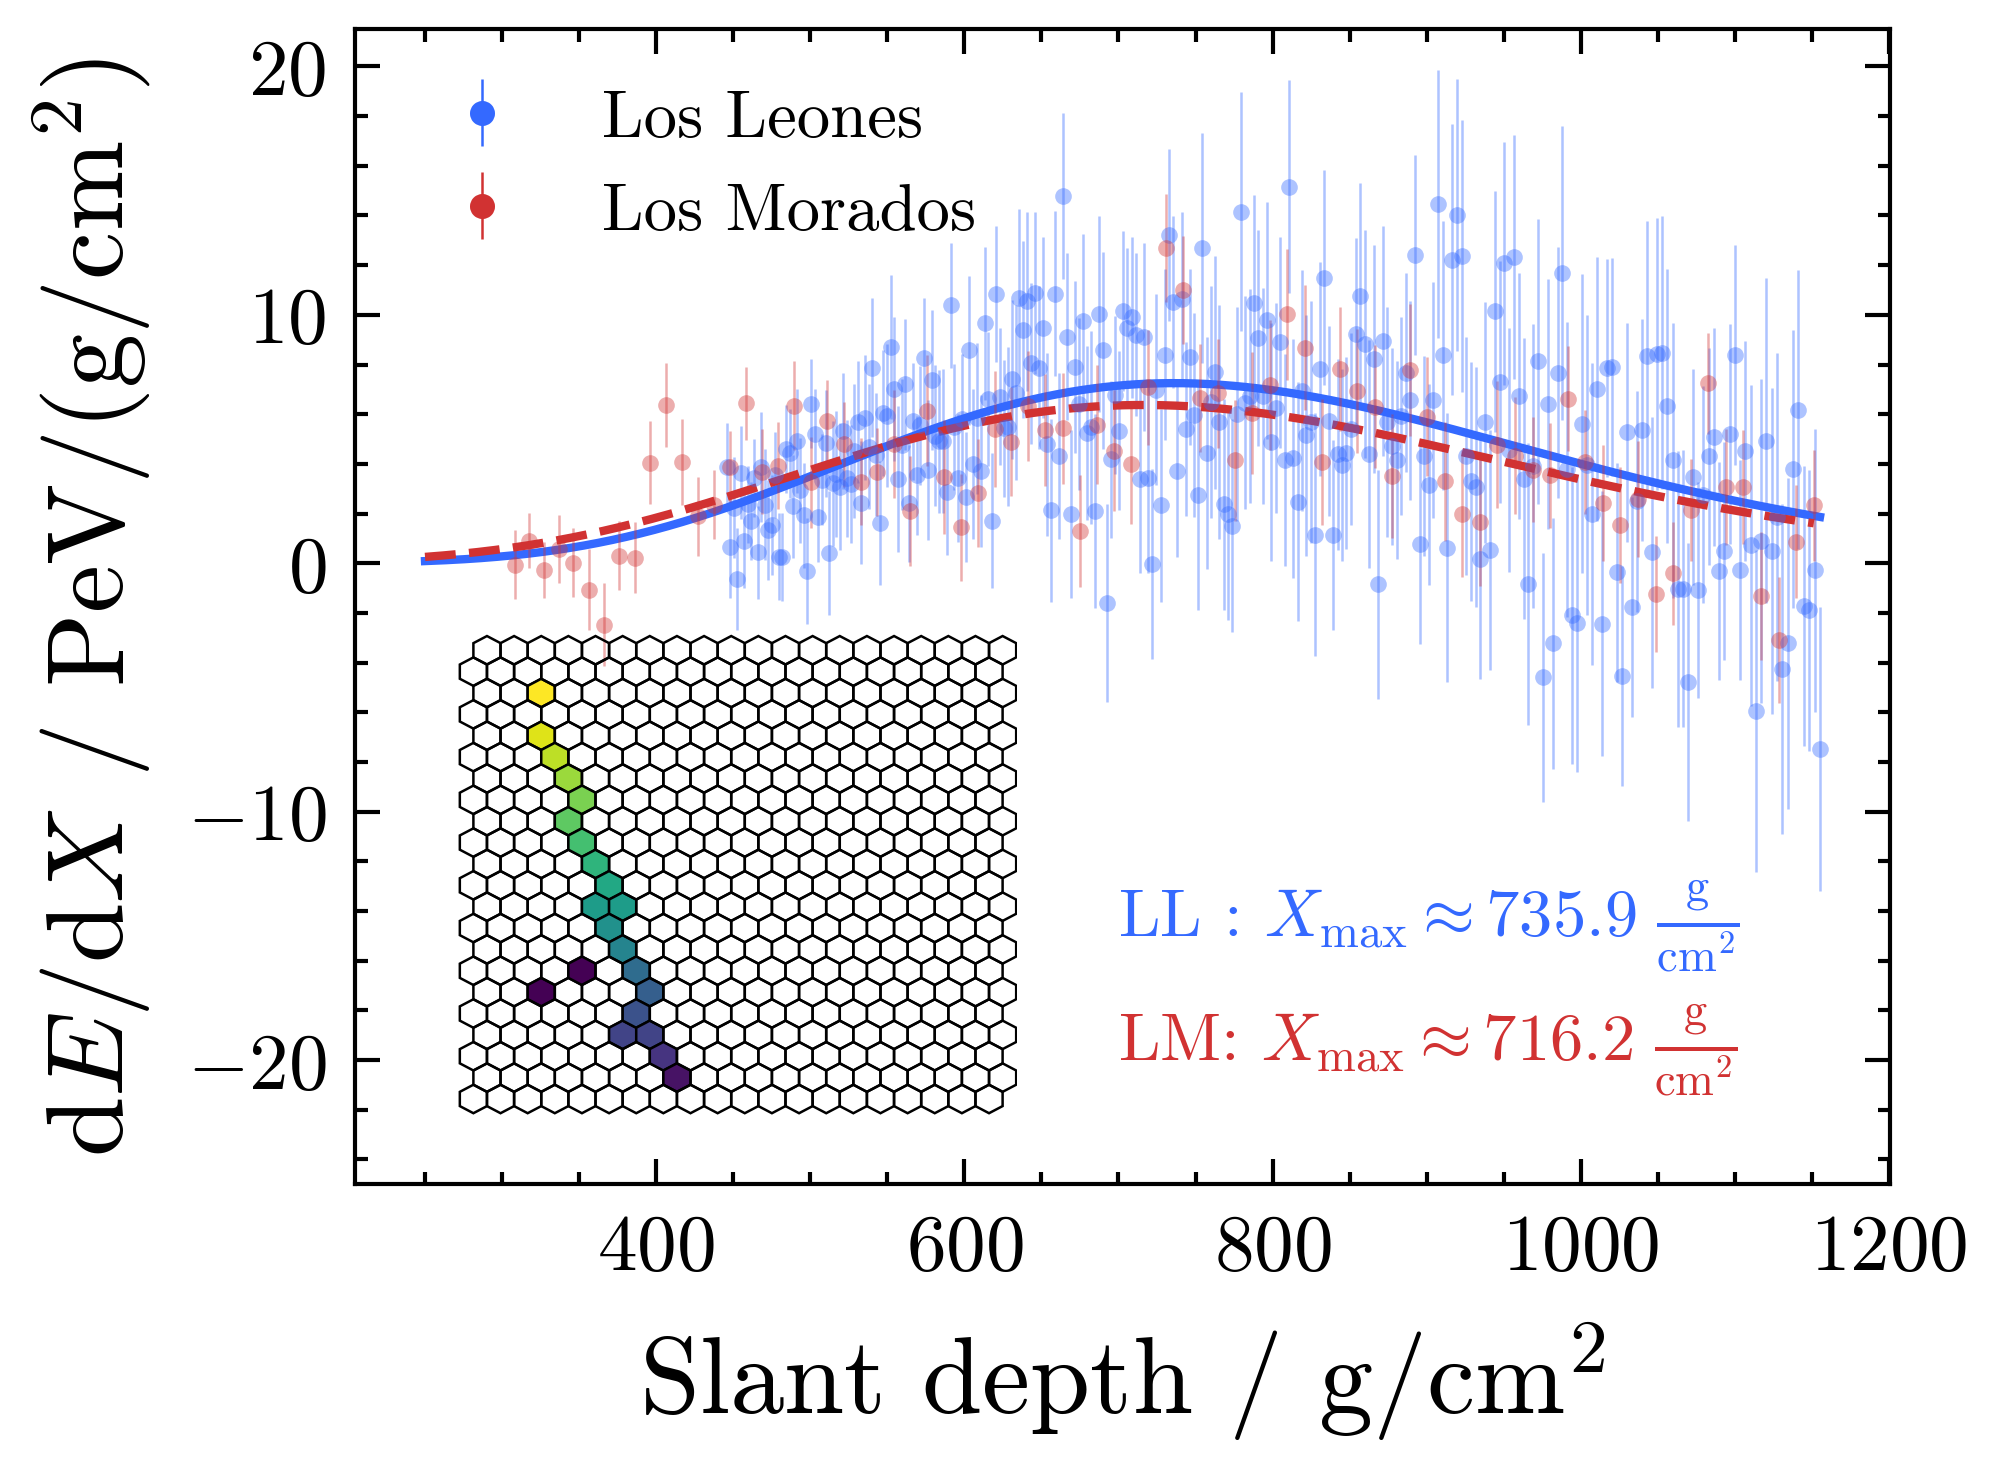

In [21]:
set_plt_style('double')

colors = {
    "ll": "#3469ff",
    "lm": "#d13232",
    "la": "#ffff00",
    "co": "#319c31",
}

c = [colors['ll'], colors['lm']]

for i, eye in enumerate(data["eyes"]):
    name = eye['name']
    
    match name:
        case "Los Leones": shortname = "LL :"
        case "Los Morados": shortname = "LM:"

    x = np.array(eye["atmDepthProf"])
    y = eye['energyDepositProf']
    dy = eye['denergyDepositProf']
    if name == "Los Leones":
        x, y, dy = x[::2], y[::2], dy[::2]

    eye['xmax'] = data['fdrec'][i]['xmax']
    eye['dEdXmax'] = data['fdrec'][i]['dEdXmax']
    eye['uspL'] = data['fdrec'][i]['uspL']
    eye['uspR'] = data['fdrec'][i]['uspR']

    dEdX = calc_profile(eye)

    X = np.linspace(250, np.max(x), 1000)
    plt.plot(X, dEdX(X), marker='none', c=c[i])
    plt.errorbar(x, y, dy, fmt='o', elinewidth=0.3,
                 c=c[i], 
                 alpha=0.4, markeredgecolor='none')
    plt.errorbar([], [], [], fmt='o', elinewidth=0.3, label=name,
                 c=c[i])
    
    plt.text(700, -15 - i*5, fr"{shortname} $X_\mathrm{{max}} \approx {eye['xmax']:.1f}\,\,\frac{{\mathrm{{g}}}}{{\mathrm{{cm}}^2}}$",
             c=c[i], fontsize=8)

plt.legend(loc=2, fontsize=8)

track_eye = data['eyes'][0]
signal_pixels = np.array(track_eye["pixelID"]) % 440
all_the_rest = [i for i in range(440) if i not in signal_pixels]
pixels = np.zeros(440)
pixels[all_the_rest] = np.nan

pixel_timing = [
    10, 9, -10, 8, 7, 5, 6, 4, 3, 1, -10, 2, 1, 0, -1, -6, -3, -4, -5, -6, -7, -9
]

for p, v in zip(signal_pixels, pixel_timing):
    pixels[p] = v

inset = plt.gca().inset_axes([0.02, 0.04, 0.45, 0.45])
PixelPlot(pixels, vmin=-10, vmax=10, ax=inset, lw=0.3)

plt.ylim(-25)
# plt.arrow(320, -5.2, 830, -2.31, lw=0.7, color='r')
# plt.arrow(412, -21, 38, 19.8, lw=0.7, color='r')
# plt.scatter([1155, 452], [-7.5, -0.8], fc='none', ec='r', lw=0.7)
plt.xlabel("Slant depth / $\mathrm{g}/\mathrm{cm}^2$")
plt.ylabel("d$E$/d$X$ / $\mathrm{PeV}/(\mathrm{g}/\mathrm{cm}^2)$")

